In [12]:
# fast ai classification example

from fastai.vision.all import *
import pandas as pd
from pathlib import Path

# 1) Load CSV
df = pd.read_csv('labels.csv')  # expects columns: fname, label
df["fname"] = [Path(p).name for p in df["img_path"]]
df["label"] = df["y_binary"]

In [13]:


# 2) Build DataLoaders (random train/valid split)
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),                 # binary as 2 categories
    get_x=ColReader('fname', pref='cropped_images/'),     # path: cropped_imgs/<fname>
    get_y=ColReader('label'),                           # label from CSV
    splitter=RandomSplitter(valid_pct=0.2, seed=42),    # 80/20 split
    item_tfms=Resize(224),                              # quick & simple
    batch_tfms=aug_transforms()                         # light defaults
).dataloaders(df, bs=64)


In [14]:

# 3) Create a learner and train
learn = vision_learner(dls, resnet18, metrics=[accuracy, RocAucBinary()])  # RocAucBinary needs fastai>=2.7
learn.fine_tune(3)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/wamster3/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 53.9MB/s]


epoch,train_loss,valid_loss,accuracy,roc_auc_score,time
0,1.074026,0.764795,0.675862,0.730977,00:16


epoch,train_loss,valid_loss,accuracy,roc_auc_score,time
0,0.750186,0.588996,0.717241,0.807512,00:15
1,0.601965,0.479121,0.766284,0.851098,00:14
2,0.513128,0.473742,0.769349,0.858562,00:14


Top losses:


AttributeError: 'ClassificationInterpretation' object has no attribute 'print_top_losses'

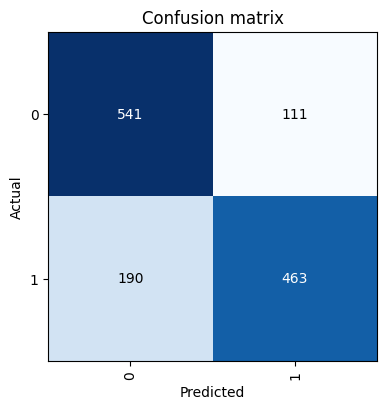

In [15]:

# 4) (Optional) Quick evaluation
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(4,4))
print("Top losses:")
interp.print_top_losses(5)